In [1]:
# %%
"""
Q9 – Expected Cash Flow Visualisation
======================================
Trade date : 05 Nov 2025   |   Spot date : 07 Nov 2025
ISIN       : IT0005599110  |   UniCredit, 160% participation, 5.45% cap, 0% floor

Produces Figure 9.1 from the report:
  • Blue bars  : uncapped FRN leg  = N × 1.6 × F_i × α_i
  • Red bars   : expected cap cost = 1.6 × Caplet_i / P(t0, T_pay)
                 shown as a NEGATIVE quantity (cost to the bondholder)
  • Dashed line: cap ceiling       = N × 5.45% × 0.25 = EUR 13.625
  • Net line   : net expected coupon = FRN − cap cost

Expected cash flow definition (risk-neutral measure):
    E^Q[Coupon_i] = N × α_i × (1.6 F_i − 1.6 × Caplet_i / (α_i × P_i))
where Caplet_i is the displaced-Black caplet PV from Q5.

Dependencies:
  • Interp_term_structure.xlsx   (bootstrapped curve, output of Q5 code)
  • q5_frn_leg.csv               (FRN leg detail,     output of Q5 code)
  • q5_cap_strip.csv             (cap strip detail,   output of Q5 code)
  • q5_floor_strip.csv           (floor strip detail, output of Q5 code)

Outputs:
  q9_expected_cashflows.png      — publication-quality figure (300 dpi)
  q9_expected_cashflows.pdf      — vector version for LaTeX inclusion
  q9_cashflows.csv               — underlying data table
"""

'\nQ9 – Expected Cash Flow Visualisation\n======================================\nTrade date : 05 Nov 2025   |   Spot date : 07 Nov 2025\nISIN       : IT0005599110  |   UniCredit, 160% participation, 5.45% cap, 0% floor\n\nProduces Figure 9.1 from the report:\n  • Blue bars  : uncapped FRN leg  = N × 1.6 × F_i × α_i\n  • Red bars   : expected cap cost = 1.6 × Caplet_i / P(t0, T_pay)\n                 shown as a NEGATIVE quantity (cost to the bondholder)\n  • Dashed line: cap ceiling       = N × 5.45% × 0.25 = EUR 13.625\n  • Net line   : net expected coupon = FRN − cap cost\n\nExpected cash flow definition (risk-neutral measure):\n    E^Q[Coupon_i] = N × α_i × (1.6 F_i − 1.6 × Caplet_i / (α_i × P_i))\nwhere Caplet_i is the displaced-Black caplet PV from Q5.\n\nDependencies:\n  • Interp_term_structure.xlsx   (bootstrapped curve, output of Q5 code)\n  • q5_frn_leg.csv               (FRN leg detail,     output of Q5 code)\n  • q5_cap_strip.csv             (cap strip detail,   output of Q5

Loaded: 35 FRN periods, 34 cap periods, 34 floor periods.

Undiscounted totals:
  FRN leg     : EUR    360.435
  Cap cost    : EUR     30.726
  Floor benefit: EUR   1.910466
  Net coupon  : EUR    331.619

PV totals (from Q5):
  FRN leg     : EUR    322.988
  Cap strip   : EUR     26.218
  Floor strip : EUR   1.621000


C:\Users\hi\AppData\Local\Temp\ipykernel_15756\4080656095.py:258: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



Saved: q9_expected_cashflows.png  |  q9_expected_cashflows.pdf


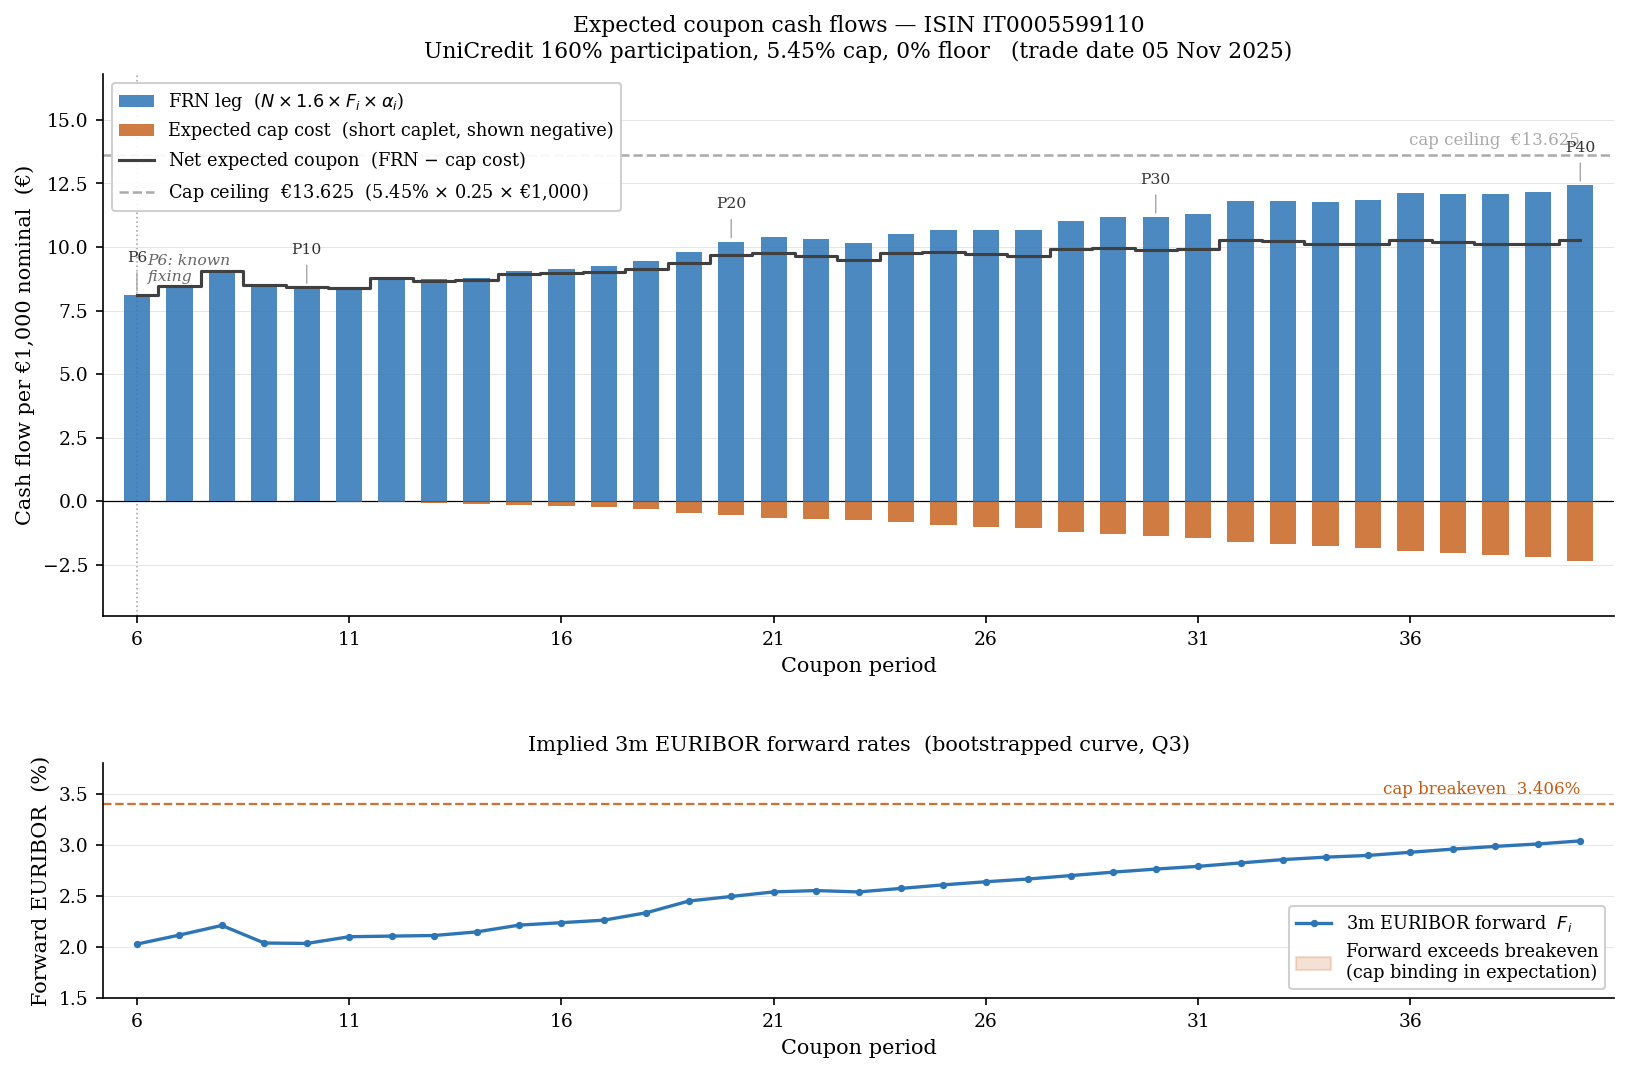

Saved: q9_cashflows.csv

Q9 — Expected Cash Flows  (selected periods)
  Period    Fwd(%)    Alpha    FRN CF   Cap cost    Net CF
  ------------------------------------------------------------
       6    2.0290   0.2528     8.116      0.000     8.116
       7    2.1175   0.2500     8.470      0.000     8.470
      10    2.0354   0.2583     8.413      0.004     8.409
      15    2.2147   0.2556     9.056      0.137     8.925
      20    2.4955   0.2556    10.204      0.540     9.685
      25    2.6094   0.2556    10.670      0.915     9.806
      30    2.7639   0.2528    11.178      1.364     9.898
      35    2.8976   0.2556    11.848      1.839    10.133
      40    3.0401   0.2556    12.431      2.331    10.263
  ------------------------------------------------------------
   TOTAL                      360.435     30.726   331.619


In [2]:


# ── 0. Imports ─────────────────────────────────────────────────────────────────
import math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from datetime import date

matplotlib.rcParams.update({
    "font.family":      "serif",
    "font.size":        10,
    "axes.titlesize":   11,
    "axes.labelsize":   10,
    "xtick.labelsize":  9,
    "ytick.labelsize":  9,
    "legend.fontsize":  9,
    "figure.dpi":       150,
    "axes.spines.top":  False,
    "axes.spines.right":False,
})

SPOT_DATE = date(2025, 11, 7)

# ── 1. Load Q5 outputs ─────────────────────────────────────────────────────────
# frn columns: Reset Date, Start Date, Payment Date, Days (30/360),
#              Accrual (30/360), DF start, DF end, Fwd Rate (ACT/360),
#              Coupon rate (x1.6), Cash flow, PV of cash flow, _source
# cap columns: Reset Date, Start Date, Payment Date, Fwd Rate, T reset (y),
#              K_eff, Flat vol, d1, d2, DF payment, Caplet (unit), Caplet PV
# flr columns: same as cap but Floorlet (unit), Floorlet PV
frn = pd.read_csv("q5_frn_leg.csv")
cap = pd.read_csv("q5_cap_strip.csv")
flr = pd.read_csv("q5_floor_strip.csv")
# DF_payment is available in all three CSVs — no external Excel file needed.

print(f"Loaded: {len(frn)} FRN periods, {len(cap)} cap periods, "
      f"{len(flr)} floor periods.")

# ── 2. Build the expected cash flow table ─────────────────────────────────────
# Period 6 is a known fixing (_source == "known fixing").
# Periods 7-40 are forward-implied (_source == "implied forward").
# cap/flr rows are matched to frn rows by Payment Date.

N       = 1_000.0
CAP_RATE = 0.0545
CAP_CEIL = N * CAP_RATE * 0.25   # EUR 13.625

rows = []

# Period 6 — known fixing (row 0)
p6 = frn[frn["_source"] == "known fixing"].iloc[0]
rows.append({
    "Period":     6,
    "Pay_Date":   p6["Payment Date"],
    "Fwd_Rate":   float("nan"),               # already fixed — no forward rate
    "Alpha":      p6["Accrual (30/360)"],
    "FRN_CF":     p6["Cash flow"],
    "Cap_cost":   0.0,
    "Floor_cost": 0.0,
    "Net_CF":     p6["Cash flow"],
    "Known":      True,
})

# Periods 7-40 — match cap/flr rows by Payment Date
for idx, (_, r_frn) in enumerate(frn[frn["_source"] == "implied forward"].iterrows()):
    period = idx + 7
    pay_dt = r_frn["Payment Date"]
    df_pay = r_frn["DF end"]               # discount factor at payment date

    frn_cf = r_frn["Cash flow"]

    # Cap cost: undiscounted expected payoff = PV / DF
    c_row    = cap[cap["Payment Date"] == pay_dt]
    cap_pv   = c_row["Caplet PV"].values[0]   if len(c_row) else 0.0
    cap_cost = cap_pv / df_pay if df_pay > 1e-8 else 0.0

    # Floor benefit
    f_row    = flr[flr["Payment Date"] == pay_dt]
    flr_pv   = f_row["Floorlet PV"].values[0] if len(f_row) else 0.0
    flr_cost = flr_pv / df_pay if df_pay > 1e-8 else 0.0

    rows.append({
        "Period":     period,
        "Pay_Date":   pay_dt,
        "Fwd_Rate":   r_frn["Fwd Rate (ACT/360)"],
        "Alpha":      r_frn["Accrual (30/360)"],
        "FRN_CF":     frn_cf,
        "Cap_cost":   cap_cost,
        "Floor_cost": flr_cost,
        "Net_CF":     frn_cf - cap_cost + flr_cost,
        "Known":      False,
    })

cf = pd.DataFrame(rows).sort_values("Period").reset_index(drop=True)

# Totals
print(f"\nUndiscounted totals:")
print(f"  FRN leg      : EUR {cf['FRN_CF'].sum():>10,.3f}")
print(f"  Cap cost     : EUR {cf['Cap_cost'].sum():>10,.3f}")
print(f"  Floor benefit: EUR {cf['Floor_cost'].sum():>10,.6f}")
print(f"  Net coupon   : EUR {cf['Net_CF'].sum():>10,.3f}")
print(f"\nPV totals (from Q5):")
print(f"  FRN leg      : EUR {frn['PV of cash flow'].sum():>10,.3f}")
print(f"  Cap strip    : EUR {cap['Caplet PV'].sum():>10,.3f}")
print(f"  Floor strip  : EUR {flr['Floorlet PV'].sum():>10,.6f}")

# ── 3. Main figure ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    2, 1,
    figsize=(13, 8),
    gridspec_kw={"height_ratios": [3, 1.3], "hspace": 0.38},
)

periods  = cf["Period"].to_numpy()
frn_cf   = cf["FRN_CF"].to_numpy()
cap_cost = cf["Cap_cost"].to_numpy()
flr_ben  = cf["Floor_cost"].to_numpy()
net_cf   = cf["Net_CF"].to_numpy()
x        = np.arange(len(periods))

# ── Panel A: stacked bar chart ─────────────────────────────────────────────────
ax = axes[0]

BAR_W   = 0.62
COL_FRN = "#2E75B6"
COL_CAP = "#C55A11"
COL_NET = "#404040"
COL_CEI = "#AAAAAA"

ax.bar(x, frn_cf, width=BAR_W, color=COL_FRN, alpha=0.85,
       label="FRN leg  ($N\\times1.6\\times F_i\\times\\alpha_i$)",
       zorder=3)

ax.bar(x, -cap_cost, width=BAR_W, color=COL_CAP, alpha=0.80,
       label="Expected cap cost  ($-1.6\\times$ Caplet$_i/P_i$)",
       zorder=4)

ax.step(x, net_cf, where="mid", color=COL_NET, linewidth=1.5,
        linestyle="-", zorder=5, label="Net expected coupon")

ax.axhline(CAP_CEIL, color=COL_CEI, linewidth=1.2, linestyle="--", zorder=2)
ax.text(len(periods) - 1, CAP_CEIL + 0.25,
        f"cap ceiling  \u20ac{CAP_CEIL:.3f}",
        ha="right", va="bottom", fontsize=8, color=COL_CEI)

ax.axvline(0, color="#888888", linewidth=0.8, linestyle=":", zorder=1, alpha=0.7)
ax.text(0.25, 8.55, "P6: known\nfixing",
        ha="left", va="bottom", fontsize=7.5, color="#666666", style="italic")

tick_locs   = x[::5]
tick_labels = [str(p) for p in periods[::5]]
ax.set_xticks(tick_locs)
ax.set_xticklabels(tick_labels)
ax.set_xlim(-0.8, len(periods) - 0.2)
ax.set_ylim(-4.5, 16.8)
ax.set_xlabel("Coupon period")
ax.set_ylabel("Cash flow per \u20ac1,000 nominal  (\u20ac)")
ax.set_title(
    "Expected coupon cash flows \u2014 ISIN IT0005599110\n"
    "UniCredit 160% participation, 5.45% cap, 0% floor   "
    "(trade date 05 Nov 2025)",
    fontsize=10.5, pad=8,
)
ax.axhline(0, color="black", linewidth=0.6, zorder=2)
ax.yaxis.grid(True, linewidth=0.35, color="#DDDDDD", zorder=0)

legend_handles = [
    mpatches.Patch(facecolor=COL_FRN, alpha=0.85,
                   label="FRN leg  ($N\\times1.6\\times F_i\\times\\alpha_i$)"),
    mpatches.Patch(facecolor=COL_CAP, alpha=0.80,
                   label="Expected cap cost  (short caplet, shown negative)"),
    Line2D([0], [0], color=COL_NET, linewidth=1.5,
           label="Net expected coupon  (FRN $-$ cap cost)"),
    Line2D([0], [0], color=COL_CEI, linewidth=1.2, linestyle="--",
           label=f"Cap ceiling  \u20ac{CAP_CEIL:.3f}  (5.45% $\\times$ 0.25 $\\times$ \u20ac1,000)"),
]
ax.legend(handles=legend_handles, loc="upper left",
          frameon=True, framealpha=0.92, edgecolor="#CCCCCC", fontsize=8.5)

# ── Panel B: forward rate curve ────────────────────────────────────────────────
ax2 = axes[1]

# Period 6 has no forward rate (fixed) — use NaN so it doesn't plot
fwd_pct = cf["Fwd_Rate"].to_numpy(dtype=float) * 100

ax2.plot(x, fwd_pct, color=COL_FRN, linewidth=1.6,
         marker="o", markersize=2.5, zorder=4, label="3m EURIBOR forward  $F_i$")

K_CAP_PCT = (0.0545 / 1.6) * 100
ax2.axhline(K_CAP_PCT, color=COL_CAP, linewidth=1.1,
            linestyle="--", zorder=2, alpha=0.85)
ax2.text(len(periods) - 1, K_CAP_PCT + 0.06,
         f"cap breakeven  {K_CAP_PCT:.3f}%",
         ha="right", va="bottom", fontsize=8, color=COL_CAP)

ax2.fill_between(x, K_CAP_PCT, fwd_pct,
                 where=(fwd_pct >= K_CAP_PCT),
                 color=COL_CAP, alpha=0.18, zorder=1,
                 label="Forward exceeds breakeven\n(cap binding in expectation)")

ax2.set_xticks(tick_locs)
ax2.set_xticklabels(tick_labels)
ax2.set_xlim(-0.8, len(periods) - 0.2)
ax2.set_ylim(1.5, 3.8)
ax2.set_xlabel("Coupon period")
ax2.set_ylabel("Forward EURIBOR  (%)")
ax2.set_title("Implied 3m EURIBOR forward rates  (bootstrapped curve, Q3)",
              fontsize=10, pad=6)
ax2.yaxis.grid(True, linewidth=0.35, color="#DDDDDD", zorder=0)
ax2.legend(loc="lower right", frameon=True, framealpha=0.92,
           edgecolor="#CCCCCC", fontsize=8.5)

# ── 4. Period annotations ──────────────────────────────────────────────────────
for p, xi in zip(periods, x):
    if p in {6, 10, 20, 30, 40}:
        axes[0].annotate(
            f"P{p}",
            xy=(xi, frn_cf[p - 6]),
            xytext=(xi, frn_cf[p - 6] + 1.2),
            ha="center", va="bottom", fontsize=7.5, color="#333333",
            arrowprops=dict(arrowstyle="-", color="#AAAAAA", linewidth=0.7),
        )

# ── 5. Save ────────────────────────────────────────────────────────────────────
plt.tight_layout()
plt.savefig("q9_expected_cashflows.png", dpi=300, bbox_inches="tight")
plt.savefig("q9_expected_cashflows.pdf", bbox_inches="tight")
print("\nSaved: q9_expected_cashflows.png  |  q9_expected_cashflows.pdf")
plt.show()

# ── 6. Save data table ─────────────────────────────────────────────────────────
cf_out = cf.copy()
cf_out["FRN_CF"]     = cf_out["FRN_CF"].round(4)
cf_out["Cap_cost"]   = cf_out["Cap_cost"].round(4)
cf_out["Floor_cost"] = cf_out["Floor_cost"].round(6)
cf_out["Net_CF"]     = cf_out["Net_CF"].round(4)
cf_out["Fwd_Rate"]   = (cf_out["Fwd_Rate"] * 100).round(4)
cf_out.rename(columns={"Fwd_Rate": "Fwd_Rate_pct"}, inplace=True)
cf_out.to_csv("q9_cashflows.csv", index=False)
print("Saved: q9_cashflows.csv")

# ── 7. Console summary ─────────────────────────────────────────────────────────
print("\n" + "="*72)
print("Q9 \u2014 Expected Cash Flows  (selected periods)")
print("="*72)
print(f"  {'Period':>6}  {'Fwd(%)':>8}  {'Alpha':>7}  "
      f"{'FRN CF':>8}  {'Cap cost':>9}  {'Net CF':>8}")
print("  " + "-"*60)
for _, r in cf.iterrows():
    if r["Period"] in {6, 7, 10, 15, 20, 25, 30, 35, 40}:
        fwd_str = f"{r['Fwd_Rate']*100:>8.4f}" if not pd.isna(r["Fwd_Rate"]) else "    fixed"
        print(f"  {int(r['Period']):>6}  "
              f"{fwd_str}  "
              f"{r['Alpha']:>7.4f}  "
              f"{r['FRN_CF']:>8.3f}  "
              f"{r['Cap_cost']:>9.3f}  "
              f"{r['Net_CF']:>8.3f}")
print("  " + "-"*60)
print(f"  {'TOTAL':>6}  {'':>8}  {'':>7}  "
      f"{cf['FRN_CF'].sum():>8.3f}  "
      f"{cf['Cap_cost'].sum():>9.3f}  "
      f"{cf['Net_CF'].sum():>8.3f}")
print("="*72)
